In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 15
TS = 0.07

In [23]:
TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
SCALER = joblib.load("./scalers/scaler.pkl")    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [24]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,...,MSE_Val_2_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_LSG_1_Theta,MSE_LSG_1_Theta,R2_LSG_2_Theta,MSE_LSG_2_Theta,R2_LSG_1Theta
0,model_arch1_r0.01_Ld0.3_Lp0.7_seed402,[1],0.3,0.7,0.01,402,-0.129449,0.280407,0.283533,0.450869,...,0.422987,-1.757810,0.209531,-2.160718,0.350535,-0.709546,0.018945,-0.867074,0.016840,NaN
1,model_arch1_r0.01_Ld0.3_Lp0.7_seed6766,[1],0.3,0.7,0.01,6766,-0.427060,0.282635,0.266696,0.470666,...,0.442172,-2.097130,0.195761,-2.786351,0.348900,-0.536260,0.014468,-0.649806,0.014280,NaN
2,model_arch1_r0.01_Ld0.3_Lp0.7_seed5475,[1],0.3,0.7,0.01,5475,-0.599553,0.244620,0.288150,0.445326,...,0.427761,-1.371656,0.179860,-1.830150,0.306327,-0.688540,-0.013036,-0.691752,0.000926,NaN
3,model_arch1_r0.01_Ld0.3_Lp0.7_seed3659,[1],0.3,0.7,0.01,3659,-0.362447,0.274098,0.286762,0.445040,...,0.426006,-1.573141,0.204819,-1.956523,0.350790,-0.687430,0.020903,-0.691605,0.015652,NaN
4,model_arch1_r0.01_Ld0.3_Lp0.7_seed2519,[1],0.3,0.7,0.01,2519,0.138895,0.269893,0.242254,0.417420,...,0.394599,-1.721828,0.208887,-2.141705,0.337054,-1.134898,0.015297,-1.404230,0.011198,NaN


In [25]:
def PickModels(target, threshold=0.5):

    # 🔹 lê arquivo
    df = pd.read_excel("BestModels-g.xlsx")

    # 🔹 cria TODAS as colunas de R2 automaticamente
    r2_cols = [f"R2_{t}_{target}" for t in TITLES if f"R2_{t}_{target}" in df.columns]

    # =========================
    # 🔥 FILTRO GLOBAL
    # =========================
    
    filtered = df[(df[r2_cols] >= threshold).all(axis=1)].copy()

    print(f"Modelos após filtro R2 >= {threshold}: {len(filtered)}")

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # =========================
    # 🔹 NORMALIZAR ARQUITETURA
    # =========================
    
    filtered["Neurons_str"] = filtered["Neurons"].apply(lambda x: str(x))

    # =========================
    # 🔥 REMOVER DUPLICADOS (MESMA ARQUITETURA)
    # =========================
    
    val_col1 = f"R2_Val_2_{target}"
    val_col2 = f"R2_Val_1_{target}"

    filtered = filtered.sort_values(
        by=[val_col1, val_col2],
        ascending=[False, False]
)

    # mantém só o melhor de cada arquitetura
    filtered_unique = filtered.drop_duplicates(subset="Neurons_str", keep="first")

    print(f"Modelos após remover arquiteturas repetidas: {len(filtered_unique)}")

    # =========================
    # 🔹 ORDENAÇÃO FINAL
    # =========================
    
    test_cols = [c for c in r2_cols if "Test" in c]
    train_cols = [c for c in r2_cols if "Train" in c]

    filtered_unique["R2_test_mean"] = filtered_unique[test_cols].mean(axis=1)
    filtered_unique["R2_train_mean"] = filtered_unique[train_cols].mean(axis=1)

    filtered_unique = filtered_unique.sort_values(
        by=[val_col1, val_col2, "R2_test_mean", "R2_train_mean"],
        ascending=False
    )

    # =========================
    # 🔥 TABELA FINAL
    # =========================
    
    final_cols = ["model", "Neurons"] + r2_cols

    final_table = filtered_unique[final_cols]

    print("\n📊 MODELOS FINAIS (SEM ARQUITETURAS REPETIDAS)")
    display(final_table)

    return final_table

In [26]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [27]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [28]:
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [29]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=0.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val_1": [], "R2_Val_2": [],
            "R2_Test_1": [], "R2_Test_2": [], 
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val_1": [], "MSE_Val_2": [],
            "MSE_Test_1": [], "MSE_Test_2": [], 
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        dy_pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(dy_pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = r2_score(dy_true[:, j], dy_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, R²diff = {mse:.4f}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [37]:
rows = PickModels("Theta", 0.0)

Modelos após filtro R2 >= 0.0: 10
Modelos após remover arquiteturas repetidas: 9

📊 MODELOS FINAIS (SEM ARQUITETURAS REPETIDAS)


C:\Users\Sarah\AppData\Local\Temp\ipykernel_18204\2191368964.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_unique["R2_test_mean"] = filtered_unique[test_cols].mean(axis=1)
C:\Users\Sarah\AppData\Local\Temp\ipykernel_18204\2191368964.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_unique["R2_train_mean"] = filtered_unique[train_cols].mean(axis=1)


,model,Neurons,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_1_Theta,R2_Val_2_Theta,R2_Test_1_Theta,R2_Test_2_Theta,R2_LSG_1_Theta,R2_LSG_2_Theta
2,model_arch21-8_r0.9_Ld0.3_Lp0.7_seed7828,"[21, 8]",0.753266,0.839527,0.849039,0.870848,0.592742,0.812088,0.469341,0.370729
0,model_arch22-14-10_r0.01_Ld0.7_Lp0.3_seed9359,"[22, 14, 10]",0.923331,0.806952,0.871018,0.835607,0.725486,0.278207,0.565345,0.273937
4,model_arch19-11-7_r0.01_Ld0.7_Lp0.3_seed9359,"[19, 11, 7]",0.854328,0.725861,0.868272,0.830485,0.528787,0.288013,0.526085,0.424369
6,model_arch8-4_r0.9_Ld0.3_Lp0.7_seed8398,"[8, 4]",0.736568,0.913659,0.833306,0.816521,0.478945,0.539526,0.129122,0.235461
5,model_arch16-11_r0.01_Ld0.7_Lp0.3_seed8398,"[16, 11]",0.826251,0.753270,0.904290,0.774262,0.457653,0.796998,0.567166,0.431906
1,model_arch18_r0.01_Ld0.3_Lp0.7_seed599,[18],0.828828,0.791270,0.906580,0.771533,0.700583,0.665978,0.597809,0.684791
7,model_arch21_r0.9_Ld0.3_Lp0.7_seed7838,[21],0.874882,0.715123,0.931355,0.697920,0.746255,0.693387,0.753049,0.685124
9,model_arch22_r0.9_Ld0.3_Lp0.7_seed416,[22],0.917153,0.762727,0.931361,0.665820,0.201867,0.274761,0.757470,0.668384
3,model_arch15-10_r0.9_Ld0.3_Lp0.7_seed7828,"[15, 10]",0.890872,0.854140,0.885712,0.642674,0.424680,0.847374,0.491804,0.478727


In [31]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model = LoadModelFromRow(row)


Theta | Train_1 -> R² = 0.8909, R²diff = 0.5006
Theta | Train_2 -> R² = 0.8541, R²diff = 0.5871
Theta | Val_1 -> R² = 0.8857, R²diff = 0.4144
Theta | Val_2 -> R² = 0.6427, R²diff = 0.5656
Theta | Test_1 -> R² = 0.4247, R²diff = 0.5595
Theta | Test_2 -> R² = 0.8474, R²diff = 0.6096
Theta | LSG_1 -> R² = 0.4918, R²diff = 0.3595
Theta | LSG_2 -> R² = 0.4787, R²diff = 0.4251


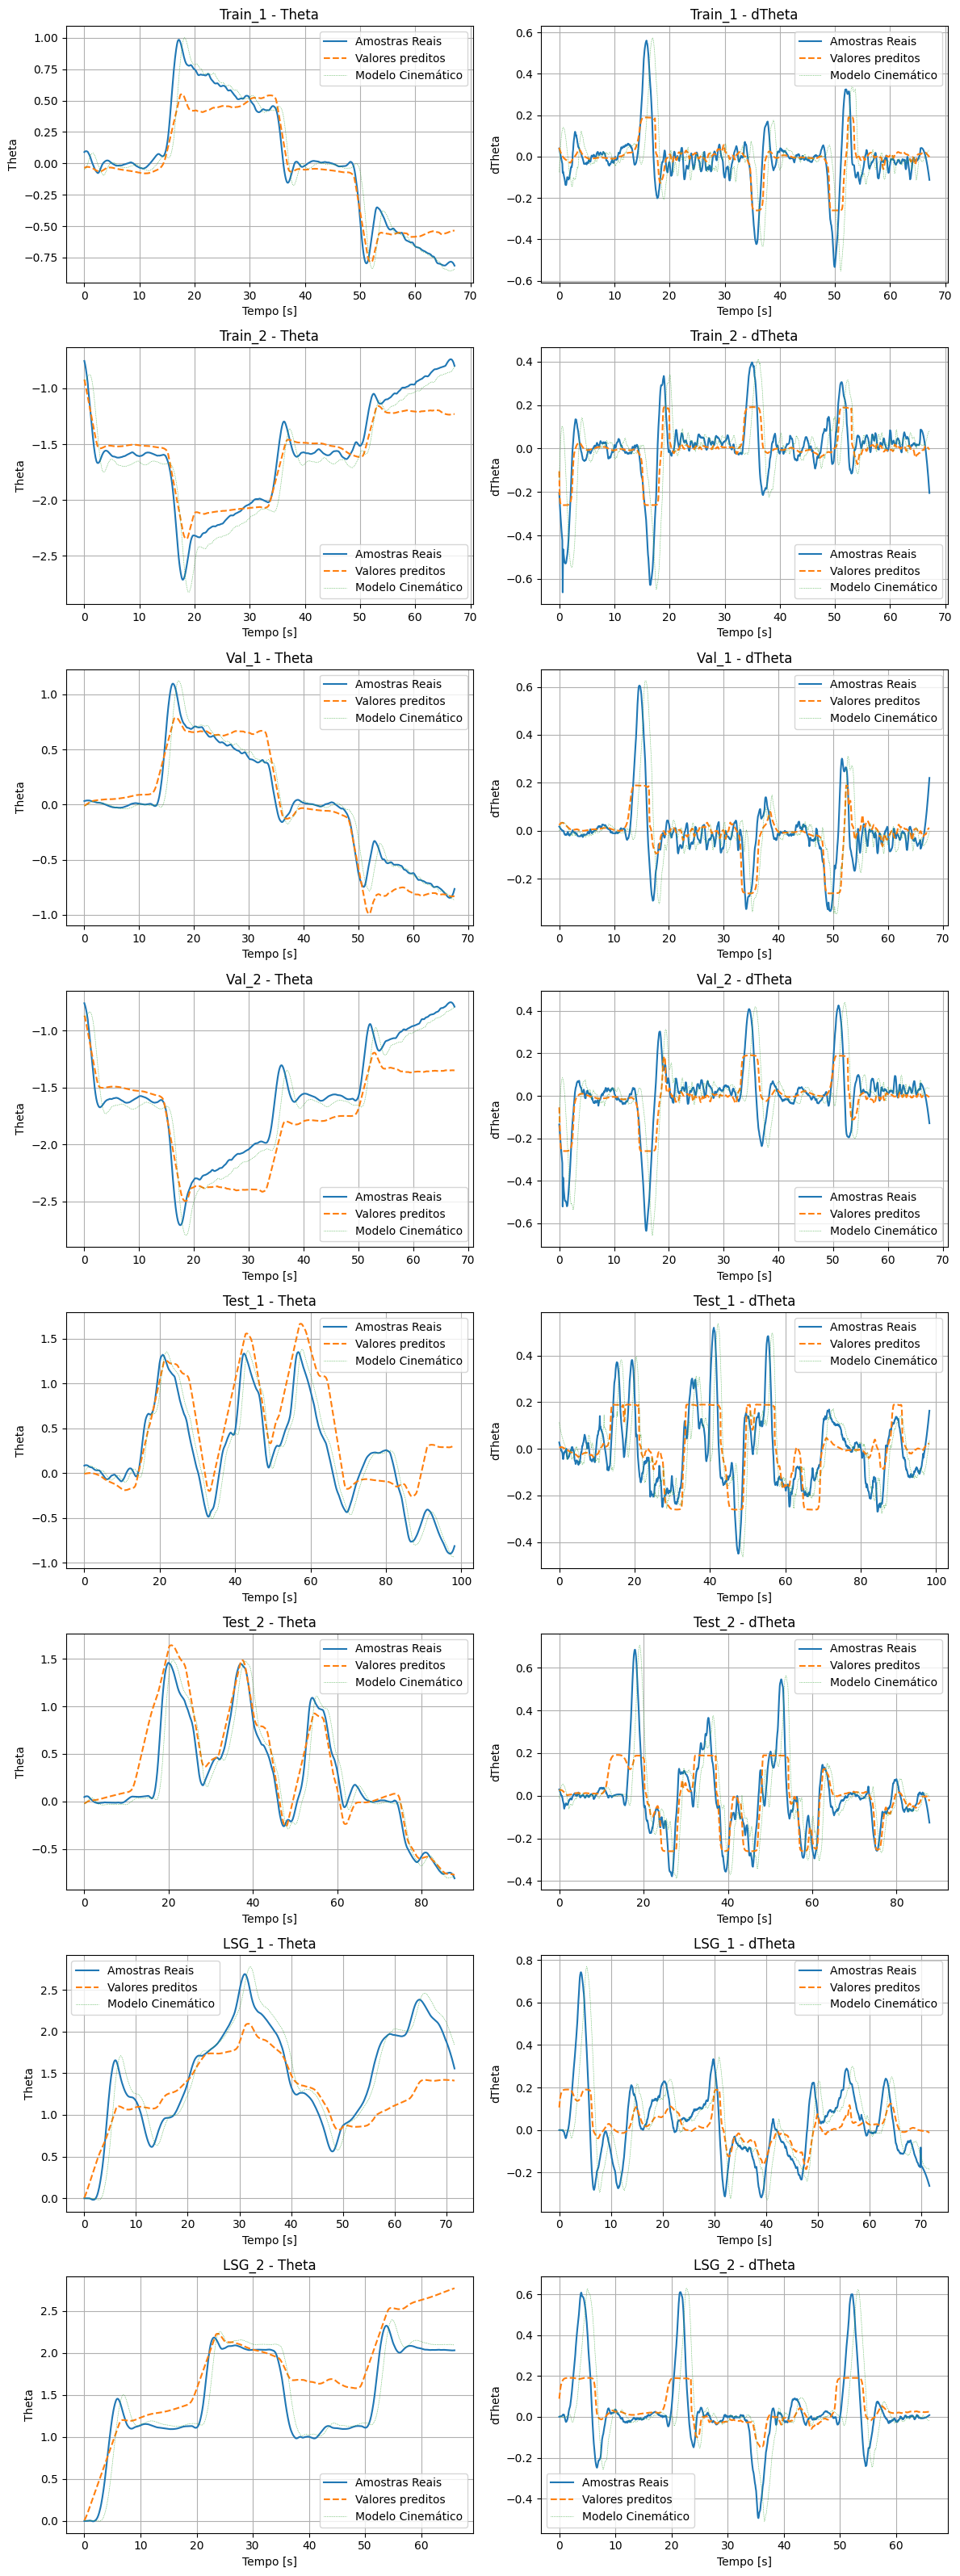

In [32]:
metrics = EvalModel(model)

In [33]:
def ExportPredictionsExcel(models_dict, filename="predicoes.xlsx"):

    writer = pd.ExcelWriter(filename, engine="openpyxl")

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x_seq, y_seq = CreateSequences(x, y, TIME_STEPS)

        time = (np.arange(0, len(x_seq), 1) * TS).round(5)

        y_true = y_seq

        # modelo cinemático
        y_cin, dy_cin = GetCin(Datasets[i])
        y_cin = y_cin[:y_true.shape[0]]

        df = pd.DataFrame({
            "Tempo": time
        })

        # =========================
        # ENTRADAS
        # =========================
        for col in PREDICTORS:
            df[col] = Datasets[i][col].iloc[TIME_STEPS:].values

        # =========================
        # SAÍDA REAL
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_real"] = y_true[:, j]

        # =========================
        # MODELO CINEMÁTICO
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_cin"] = y_cin[:, j]

        # =========================
        # MODELOS TREINADOS
        # =========================
        for model_name, model in models_dict.items():

            dy_pred = model(tf.convert_to_tensor(x_seq, dtype=tf.float32)).numpy()
            dy_pred = OUT_SCALER.inverse_transform(dy_pred)

            y_pred = np.zeros_like(dy_pred)

            init_vals = np.array([
                Datasets[i][name].iloc[0] for name in TARGET_INT
            ])

            for j in range(len(TARGET_INT)):
                y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

            for j, name in enumerate(TARGET_INT):
                df[f"{name}_pred_{model_name}"] = y_pred[:, j]

        # nome da sheet (limite Excel = 31 chars)
        sheet_name = TITLES[i][:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

    writer.close()
    print(f"Excel salvo em: {filename}")

In [34]:
models_dict = {}
for _, row in rows.iterrows():
    model_name = row["model"]
    model = LoadModelFromRow(row)
    models_dict[model_name] = model

ExportPredictionsExcel(models_dict, "resultados_comparacao.xlsx")

Excel salvo em: resultados_comparacao.xlsx


In [35]:
def EnsembleFromExcel(input_file, weights, output_metrics="Metricas.xlsx"):

    # normalizar pesos
    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}

    xls = pd.ExcelFile(input_file)

    metrics = []

    writer = pd.ExcelWriter(input_file, engine="openpyxl", mode="a", if_sheet_exists="replace")

    for sheet in xls.sheet_names:

        df = pd.read_excel(xls, sheet_name=sheet)

        # detectar targets automaticamente
        targets = list(set([col.split("_")[0] for col in df.columns if "_real" in col]))

        for target in targets:

            # =========================
            # COLUNAS
            # =========================
            y_true = df[f"{target}_real"].values

            # modelos disponíveis no df
            model_cols = {
                name: f"{target}_pred_{name}"
                for name in weights.keys()
                if f"{target}_pred_{name}" in df.columns
            }

            # =========================
            # ENSEMBLE
            # =========================
            y_ens = np.zeros_like(y_true, dtype=float)

            for model_name, col in model_cols.items():
                y_ens += weights[model_name] * df[col].values

            # salvar no dataframe
            df[f"{target}_ens"] = y_ens

            # =========================
            # MÉTRICAS
            # =========================
            # modelos individuais
            for model_name, col in model_cols.items():

                r2 = r2_score(y_true, df[col].values)
                mse = mean_squared_error(y_true, df[col].values)

                metrics.append({
                    "Dataset": sheet,
                    "Target": target,
                    "Model": model_name,
                    "R2": r2,
                    "MSE": mse
                })

            # ensemble
            r2_ens = r2_score(y_true, y_ens)
            mse_ens = mean_squared_error(y_true, y_ens)

            metrics.append({
                "Dataset": sheet,
                "Target": target,
                "Model": "ENSEMBLE",
                "R2": r2_ens,
                "MSE": mse_ens
            })

        # sobrescrever sheet com ensemble
        df.to_excel(writer, sheet_name=sheet, index=False)

    writer.close()

    # =========================
    # SALVAR MÉTRICAS
    # =========================
    df_metrics = pd.DataFrame(metrics)

    with pd.ExcelWriter(output_metrics, engine="openpyxl") as writer:

        df_metrics.to_excel(writer, sheet_name="raw", index=False)

        # pivot R2
        pivot_r2 = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="R2"
        )

        # pivot MSE
        pivot_mse = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="MSE"
        )

        pivot_r2.to_excel(writer, sheet_name="R2")
        pivot_mse.to_excel(writer, sheet_name="MSE")

    print("✔ Ensemble adicionado ao Excel original")
    print(f"✔ Métricas salvas em: {output_metrics}")

In [36]:
models = rows["model"].tolist()
n = len(models)

weights = {model: 1/n for model in models}
EnsembleFromExcel("resultados_comparacao.xlsx", weights)

✔ Ensemble adicionado ao Excel original
✔ Métricas salvas em: Metricas.xlsx
